# Zusatzanalyse: Zeitliche Entwicklung der gemeldeten TB-Faelle

Der WHO-Bericht beschreibt deutliche Auswirkungen der COVID-19-Pandemie auf TB-Diagnostik und Fallmeldungen. Rueckgaenge der gemeldeten Faelle im Jahr 2020 koennen daher eine eingeschraenkte Diagnostik widerspiegeln. Fuer die Jahre 2021 bis 2023 beschreibt der Bericht anschliessend eine Erholung der Diagnostik und erneut steigende Fallmeldungen.

Diese Zusatzanalyse prueft, ob sich dieses zeitliche Muster auch in den bereinigten Projektdaten zeigt. Sie ist zunaechst getrennt vom Hauptnotebook, weil noch entschieden werden soll, ob und wie sie in die Projektanalyse aufgenommen wird.

## 1. Setup und Datenimport

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import friedmanchisquare
import statsmodels.formula.api as smf

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
tb_cases = pd.read_csv("cleaned_data/tb_cases_analysis_cleaned.csv")

# Kleine Ausgangsfallzahlen wurden bereits im Cleaning markiert.
tb_cases = tb_cases[~tb_cases["low_c_newinc_flag"]].copy()

print("Beobachtungen:", len(tb_cases))
print("Laender:", tb_cases["iso3"].nunique())
print("Ausgangsjahre:", sorted(tb_cases["year"].unique()))

Beobachtungen: 516
Laender: 135
Ausgangsjahre: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


## 2. Vergleichbarkeit der Jahre

Zuerst wird geprueft, wie viele Beobachtungen und Laender pro Jahr enthalten sind. Eine Veraenderung der Zusammensetzung koennte sonst faelschlich wie ein zeitlicher Effekt aussehen.

In [3]:
year_coverage = tb_cases.groupby("year").agg(
    observations=("iso3", "size"),
    countries=("iso3", "nunique"),
)

year_coverage

,observations,countries
year,,
2019,94,94
2020,101,101
2021,106,106
2022,107,107
2023,108,108


In [4]:
required_years = set(tb_cases["year"].unique())
country_years = tb_cases.groupby("iso3")["year"].agg(set)
complete_countries = country_years[country_years.apply(lambda years: required_years.issubset(years))].index

tb_cases_balanced = tb_cases[tb_cases["iso3"].isin(complete_countries)].copy()

print("Laender mit Daten fuer alle Ausgangsjahre:", len(complete_countries))
print("Beobachtungen im konstanten Laender-Panel:", len(tb_cases_balanced))

Laender mit Daten fuer alle Ausgangsjahre: 70
Beobachtungen im konstanten Laender-Panel: 350


## 3. Fallzahl-Veraenderung nach Ausgangsjahr

Das Ausgangsjahr bezeichnet das Jahr der Screening-Daten. Die Zielvariable beschreibt die prozentuale Veraenderung der gemeldeten TB-Faelle zum jeweiligen Folgejahr. Beispielsweise steht 2019 fuer die Veraenderung von 2019 zu 2020.

In [5]:
year_change_summary = tb_cases.groupby("year")[
    "c_newinc_percent_change_next_year"
].agg(["count", "median", "mean"]).round(2)

year_change_summary

,count,median,mean
year,,,
2019,94,-15.18,-15.01
2020,101,2.46,2.98
2021,106,9.28,11.38
2022,107,5.17,8.79
2023,108,-0.04,-1.40


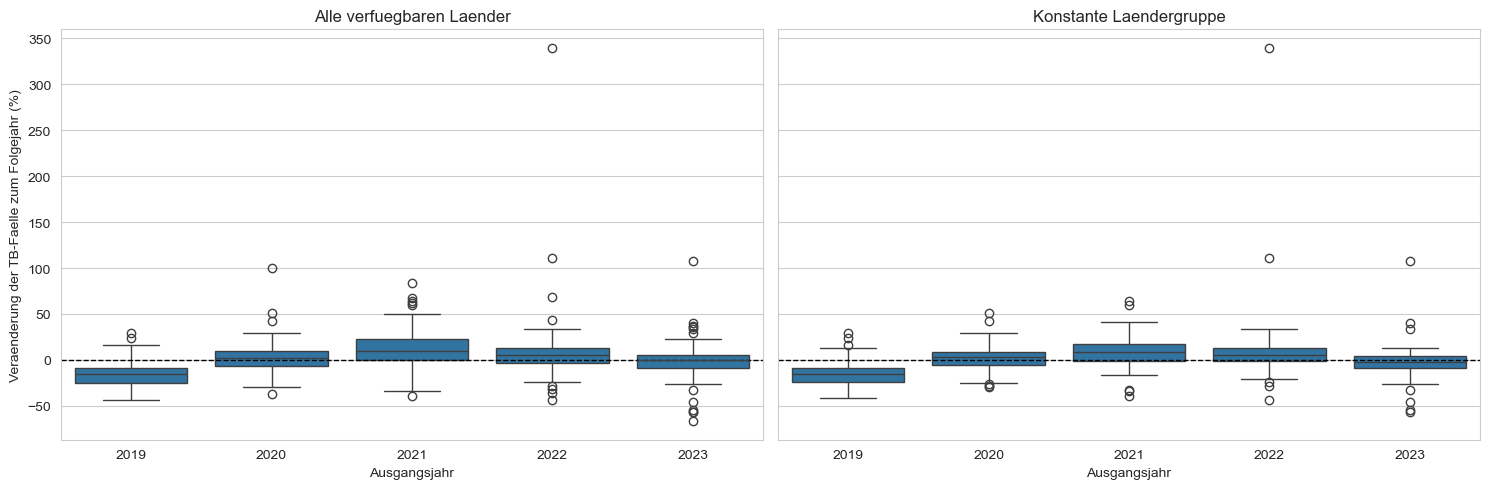

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

sns.boxplot(
    data=tb_cases,
    x="year",
    y="c_newinc_percent_change_next_year",
    ax=axes[0],
)
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Alle verfuegbaren Laender")
axes[0].set_xlabel("Ausgangsjahr")
axes[0].set_ylabel("Veraenderung der TB-Faelle zum Folgejahr (%)")

sns.boxplot(
    data=tb_cases_balanced,
    x="year",
    y="c_newinc_percent_change_next_year",
    ax=axes[1],
)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Konstante Laendergruppe")
axes[1].set_xlabel("Ausgangsjahr")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

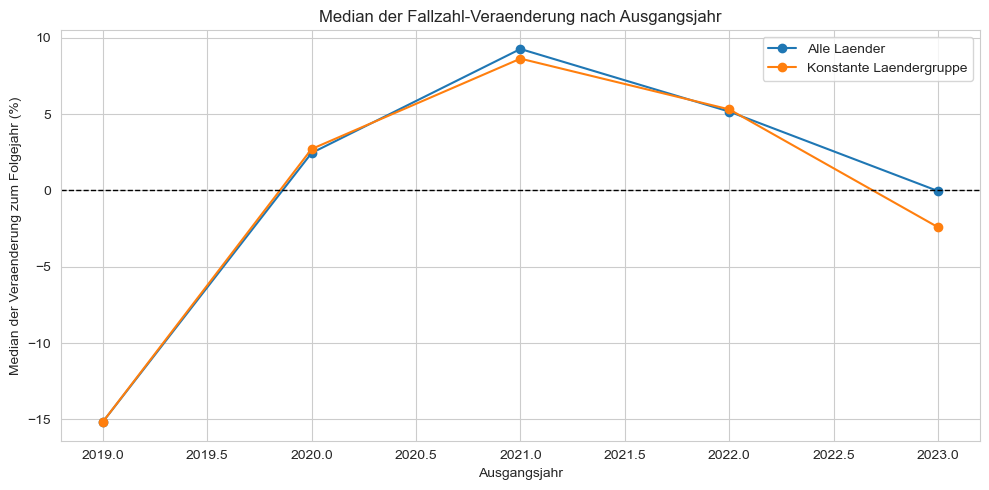

In [7]:
median_change_all = tb_cases.groupby("year")[
    "c_newinc_percent_change_next_year"
].median()

median_change_balanced = tb_cases_balanced.groupby("year")[
    "c_newinc_percent_change_next_year"
].median()

plt.figure(figsize=(10, 5))
plt.plot(median_change_all.index, median_change_all.values, marker="o", label="Alle Laender")
plt.plot(
    median_change_balanced.index,
    median_change_balanced.values,
    marker="o",
    label="Konstante Laendergruppe",
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Median der Fallzahl-Veraenderung nach Ausgangsjahr")
plt.xlabel("Ausgangsjahr")
plt.ylabel("Median der Veraenderung zum Folgejahr (%)")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Rueckgang, stabiler Verlauf oder Anstieg

Wie im Hauptnotebook wird eine Veraenderung zwischen -3% und +3% als stabil gewertet. Dadurch wird sichtbar, ob sich nach Kalenderjahr vor allem der Anteil sinkender oder steigender Fallmeldungen veraendert.

In [8]:
def classify_case_change(value):
    if value < -3:
        return "decrease"
    if value > 3:
        return "increase"
    return "stable"

tb_cases_balanced["case_change_category"] = tb_cases_balanced[
    "c_newinc_percent_change_next_year"
].apply(classify_case_change)

change_by_year = pd.crosstab(
    tb_cases_balanced["year"],
    tb_cases_balanced["case_change_category"],
    normalize="index",
).mul(100).round(1)[["decrease", "stable", "increase"]]

change_by_year

case_change_category,decrease,stable,increase
year,,,
2019,81.4,7.1,11.4
2020,31.4,20.0,48.6
2021,24.3,14.3,61.4
2022,22.9,14.3,62.9
2023,48.6,22.9,28.6


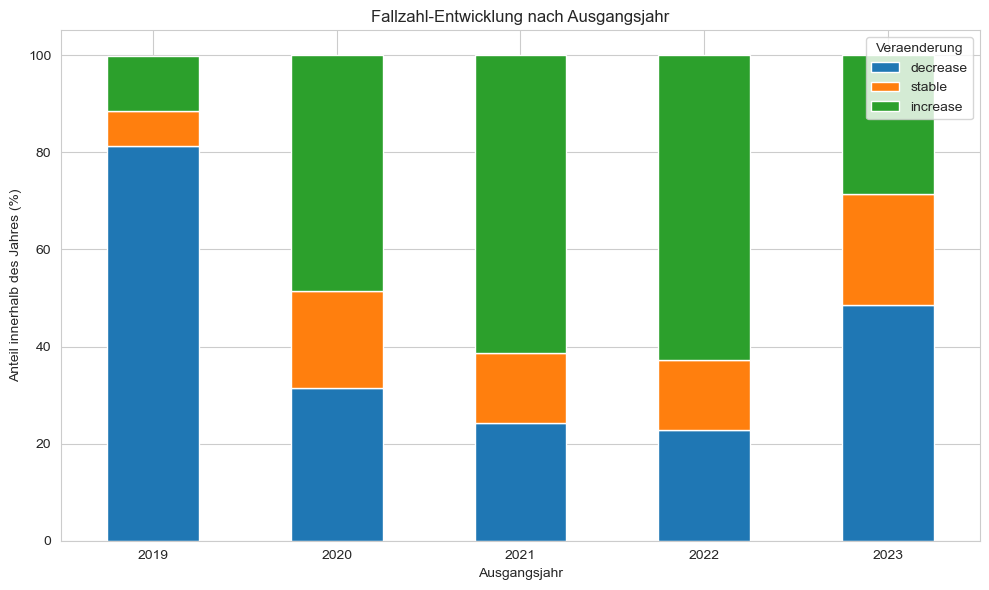

In [9]:
change_by_year.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Fallzahl-Entwicklung nach Ausgangsjahr")
plt.xlabel("Ausgangsjahr")
plt.ylabel("Anteil innerhalb des Jahres (%)")
plt.xticks(rotation=0)
plt.legend(title="Veraenderung")
plt.tight_layout()
plt.show()

## 5. Zeitlicher Verlauf nach WHO-Region

Die Heatmap zeigt, ob das zeitliche Muster in allen WHO-Regionen auftritt oder vor allem durch einzelne Regionen gepraegt wird. Verwendet wird weiterhin die konstante Laendergruppe.

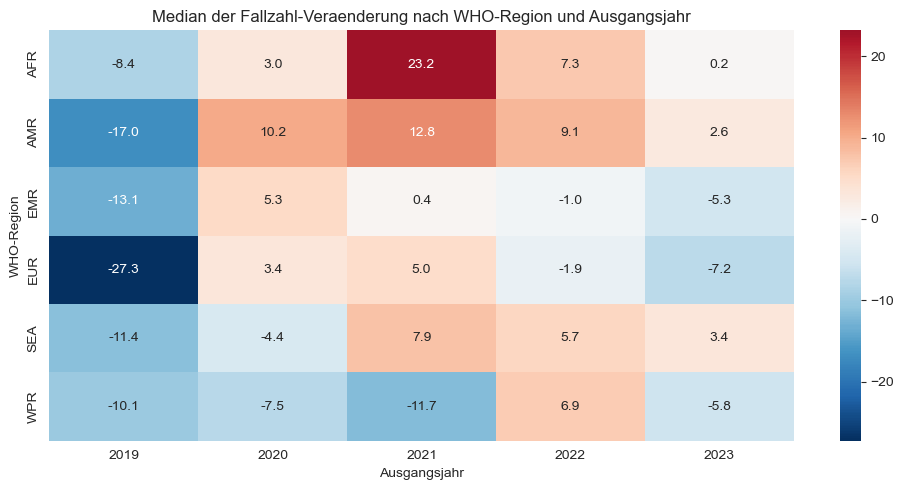

In [10]:
region_year_medians = tb_cases_balanced.pivot_table(
    index="g_whoregion",
    columns="year",
    values="c_newinc_percent_change_next_year",
    aggfunc="median",
)

plt.figure(figsize=(10, 5))
sns.heatmap(
    region_year_medians,
    annot=True,
    fmt=".1f",
    cmap="RdBu_r",
    center=0,
)
plt.title("Median der Fallzahl-Veraenderung nach WHO-Region und Ausgangsjahr")
plt.xlabel("Ausgangsjahr")
plt.ylabel("WHO-Region")
plt.tight_layout()
plt.show()

## 6. Entwicklung von Screening und TPT

Ergaenzend wird geprueft, ob sich die medianen Screening- und Praeventionsraten im gleichen Zeitraum veraendert haben. Dies beschreibt die zeitliche Entwicklung der Massnahmen, belegt aber noch keinen ursachlichen Einfluss auf die Fallzahlen.

In [11]:
exposure_cols = [
    "contact_screening_rate",
    "tpt_start_rate",
    "tpt_completion_rate",
]

exposure_by_year = tb_cases_balanced.groupby("year")[exposure_cols].median()
exposure_by_year

,contact_screening_rate,tpt_start_rate,tpt_completion_rate
year,,,
2019,0.868530,0.118002,0.837838
2020,0.873019,0.114313,0.854227
2021,0.881966,0.142440,0.877298
2022,0.874580,0.127789,0.872542
2023,0.879837,0.136275,0.852083


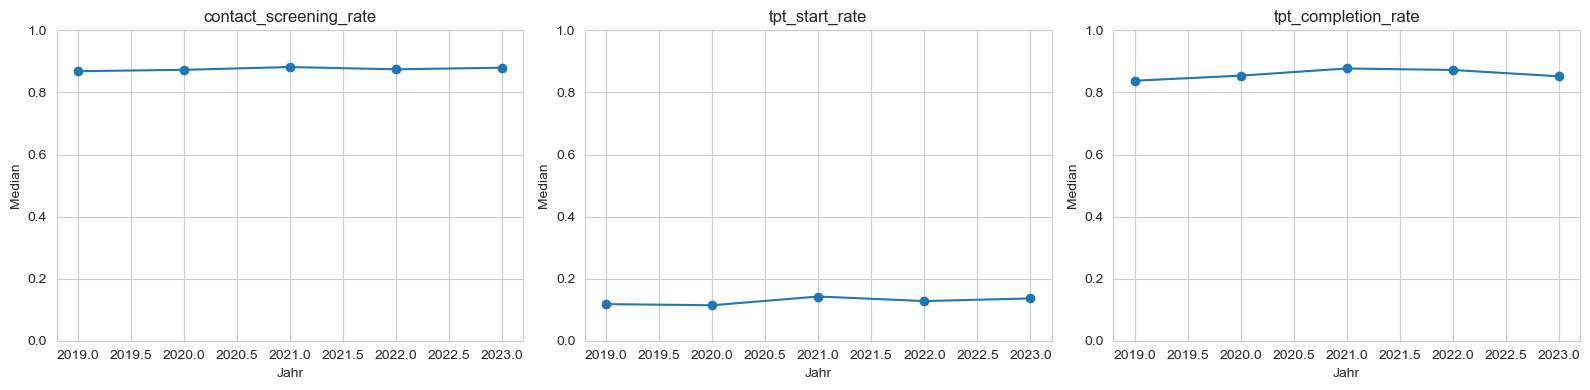

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)

for i, col in enumerate(exposure_cols):
    axes[i].plot(exposure_by_year.index, exposure_by_year[col], marker="o")
    axes[i].set_title(col)
    axes[i].set_xlabel("Jahr")
    axes[i].set_ylabel("Median")
    axes[i].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 7. Statistische Pruefung des Jahreseffekts

Der Friedman-Test prueft, ob sich die Verteilungen der Fallzahl-Veraenderung zwischen den Ausgangsjahren unterscheiden. Er beruecksichtigt, dass dieselben Laender wiederholt beobachtet werden. Der Test sagt nicht, welches Jahr sich von welchem anderen Jahr unterscheidet und belegt keine Ursache.

In [13]:
friedman_data = tb_cases_balanced.pivot(
    index="country",
    columns="year",
    values="c_newinc_percent_change_next_year",
).dropna()
friedman_years = sorted(friedman_data.columns)

friedman_result = friedmanchisquare(
    *(friedman_data[year] for year in friedman_years)
)

print("Friedman-Teststatistik:", round(friedman_result.statistic, 3))
print("p-Wert:", round(friedman_result.pvalue, 6))

Friedman-Teststatistik: 77.566
p-Wert: 0.0


## 8. Kontrollierte lineare Regression

Die bisherigen Korrelationen betrachten jeweils nur zwei Variablen. Mit der linearen Regression wird geprueft, ob der Zusammenhang der Ausgangsraten mit der Fallzahl-Veraenderung bestehen bleibt, wenn Unterschiede zwischen den Jahren und WHO-Regionen beruecksichtigt werden.

Dafuer werden je Ausgangsvariable drei Varianten derselben Regression verglichen:

1. nur die Ausgangsvariable,
2. zusaetzlich das Ausgangsjahr,
3. zusaetzlich das Ausgangsjahr und die WHO-Region.

Das Jahr wird als Kategorie behandelt, weil kein gleichmaessiger Jahrestrend angenommen werden kann. Beobachtungen mit markierten Randwerten der jeweils untersuchten Ausgangsrate werden ausgeschlossen. Da dieselben Laender mehrfach vorkommen, werden die Standardfehler nach Land gruppiert. Die Analyse untersucht Zusammenhaenge und belegt keine Ursache.

In [16]:
target_col = "c_newinc_percent_change_next_year"

exposure_labels = {
    "contact_screening_rate": "Contact-Screening",
    "tpt_start_rate": "TPT-Start",
    "tpt_completion_rate": "TPT-Abschluss",
}

model_formulas = {
    "ohne Kontrolle": "{target} ~ {exposure}",
    "mit Jahr": "{target} ~ {exposure} + C(year)",
    "mit Jahr und WHO-Region": (
        "{target} ~ {exposure} + C(year) + C(g_whoregion)"
    ),
}

regression_results = []

for exposure_col, exposure_label in exposure_labels.items():
    edge_flag_col = f"{exposure_col}_edge_flag"
    exposure_percent_col = f"{exposure_col}_percent"

    model_data = tb_cases.loc[
        ~tb_cases[edge_flag_col],
        ["iso3", "year", "g_whoregion", target_col, exposure_col],
    ].dropna().copy()
    model_data[exposure_percent_col] = model_data[exposure_col] * 100

    for model_name, formula_template in model_formulas.items():
        formula = formula_template.format(
            target=target_col,
            exposure=exposure_percent_col,
        )
        result = smf.ols(formula, data=model_data).fit(
            cov_type="cluster",
            cov_kwds={"groups": model_data["iso3"]},
        )
        confidence_interval = result.conf_int().loc[exposure_percent_col]

        regression_results.append({
            "Ausgangsvariable": exposure_label,
            "Regression": model_name,
            "n": int(result.nobs),
            "Koeffizient": result.params[exposure_percent_col],
            "CI_unten": confidence_interval.iloc[0],
            "CI_oben": confidence_interval.iloc[1],
            "p_Wert": result.pvalues[exposure_percent_col],
            "R_Quadrat": result.rsquared,
        })

regression_table = pd.DataFrame(regression_results)
regression_table.round(3)

,Ausgangsvariable,Regression,n,Koeffizient,CI_unten,CI_oben,p_Wert,R_Quadrat
0,Contact-Screening,ohne Kontrolle,391,-0.053,-0.198,0.092,0.474,0.003
1,Contact-Screening,mit Jahr,391,-0.058,-0.203,0.086,0.427,0.161
2,Contact-Screening,mit Jahr und WHO-Region,391,-0.053,-0.201,0.095,0.485,0.176
3,TPT-Start,ohne Kontrolle,459,-0.047,-0.124,0.030,0.232,0.002
4,TPT-Start,mit Jahr,459,-0.036,-0.107,0.036,0.326,0.142
5,TPT-Start,mit Jahr und WHO-Region,459,-0.031,-0.099,0.036,0.367,0.163
6,TPT-Abschluss,ohne Kontrolle,276,0.040,-0.088,0.168,0.542,0.002
7,TPT-Abschluss,mit Jahr,276,-0.001,-0.132,0.130,0.987,0.243
8,TPT-Abschluss,mit Jahr und WHO-Region,276,-0.013,-0.144,0.118,0.847,0.275


Der Koeffizient beschreibt, um wie viele Prozentpunkte sich die Fallzahl-Veraenderung im Folgejahr durchschnittlich veraendert, wenn die jeweilige Ausgangsrate um einen Prozentpunkt steigt. Das Konfidenzintervall zeigt die Unsicherheit dieser Schaetzung. Schneidet es die Nulllinie, ist kein eindeutiger positiver oder negativer Zusammenhang erkennbar.

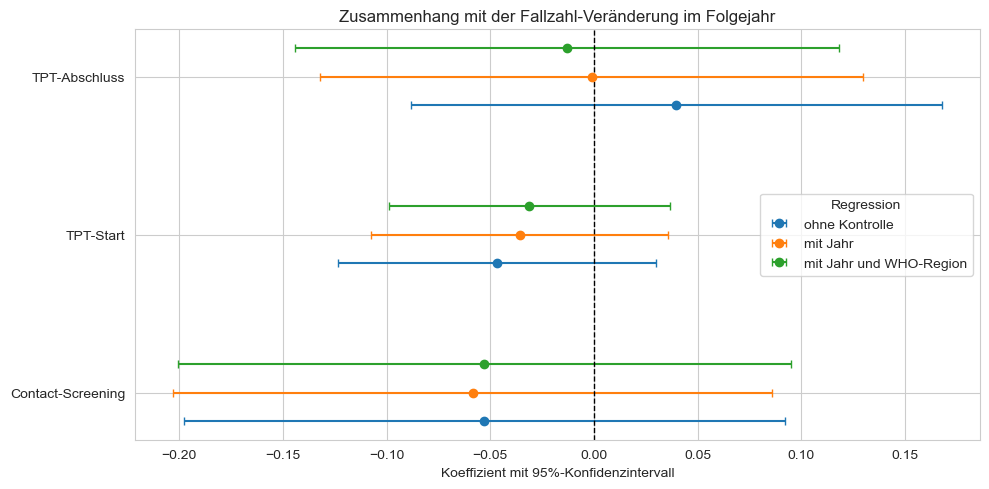

In [17]:
plt.figure(figsize=(10, 5))

model_order = list(model_formulas)
exposure_order = list(exposure_labels.values())
offsets = [-0.18, 0, 0.18]

for offset, model_name in zip(offsets, model_order):
    plot_data = regression_table[
        regression_table["Regression"] == model_name
    ].set_index("Ausgangsvariable").loc[exposure_order]
    positions = [position + offset for position in range(len(exposure_order))]

    plt.errorbar(
        plot_data["Koeffizient"],
        positions,
        xerr=[
            plot_data["Koeffizient"] - plot_data["CI_unten"],
            plot_data["CI_oben"] - plot_data["Koeffizient"],
        ],
        fmt="o",
        capsize=3,
        label=model_name,
    )

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.yticks(range(len(exposure_order)), exposure_order)
plt.xlabel("Koeffizient mit 95%-Konfidenzintervall")
plt.ylabel("")
plt.title("Zusammenhang mit der Fallzahl-Veränderung im Folgejahr")
plt.legend(title="Regression")
plt.tight_layout()
plt.show()

## 9. Vorlaeufige Interpretation

Bei der Interpretation muss zwischen tatsaechlicher TB-Inzidenz und gemeldeten TB-Faellen unterschieden werden. Ein Rueckgang der Meldungen kann durch weniger Erkrankungen entstehen, aber auch durch eingeschraenkte Diagnostik oder Untererfassung. Umgekehrt koennen steigende Meldungen eine Zunahme der Erkrankungen oder eine Erholung beziehungsweise Verbesserung der Fallfindung widerspiegeln.

Der WHO-Bericht beschreibt fuer 2020 einen starken Einbruch der TB-Diagnostik und fuer 2021 bis 2023 anschliessende Anstiege. Dieses Muster zeigt sich auch in der konstanten Laendergruppe. Das Kalenderjahr und die pandemiebedingten Veraenderungen der Diagnostik sind daher fuer die Fallzahlentwicklung offenbar wichtiger als die Contact-Screening-Rate allein.

Auch in der kontrollierten Regression zeigt sich fuer keine der drei Ausgangsraten ein eindeutiger Zusammenhang mit der Fallzahl-Veraenderung im Folgejahr. Die Koeffizienten bleiben klein und alle Konfidenzintervalle schneiden die Nulllinie. Durch die Beruecksichtigung des Jahres steigt der erklaerte Anteil der Streuung jedoch deutlich. Das bestaetigt den starken zeitlichen Einfluss, ohne einen zusaetzlichen Zusammenhang der Screening- oder TPT-Raten zu zeigen.